# Collocation from nodes to a solved problem

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pierrelux/rlbook/blob/main/lab/notebooks/08_collocation_from_nodes.ipynb)

This notebook applies the recipe of the chapter
[Continuous-Time Transcription and Collocation](https://pierrelux.github.io/rlbook/continuous-time-collocation)
to one small problem. It follows the steps of the chapter's algorithm: compute
the rule once, allocate the variables, assemble each interval, connect the
controls, then solve and check. The coefficients of the rule are computed by
hand for two nodes, then by a few lines of code that accept any nodes. The
last section repeats the construction with derivatives in place of integrals.

The notebook uses NumPy, SciPy, and Matplotlib, and runs in a few seconds.

## The problem

A pendulum hangs at rest. It must stand upright and at rest at time $T=4$,
using as little torque as possible. Let $\theta$ be the angle measured from
the hanging position, $\omega$ the angular velocity, and $u$ the torque. In
units where the natural frequency is one, the state
$\mathbf x=(\theta,\omega)$ and the control $u$ satisfy

$$
\dot\theta=\omega,\qquad \dot\omega=-\sin\theta+u.
$$

Writing these dynamics as $\dot{\mathbf x}=\mathbf f(\mathbf x,u)$, the
problem is

$$
\min_{\mathbf x(\cdot),u(\cdot)} \int_0^T u(t)^2 dt
\quad\text{subject to}\quad
\dot{\mathbf x}=\mathbf f(\mathbf x,u),\quad
\mathbf x(0)=(0,0),\quad
\mathbf x(T)=(\pi,0).
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
from numpy.polynomial import Polynomial
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})


def f(x, u):
    # Pendulum dynamics: x = (angle, angular velocity), u = torque.
    theta, omega = x
    return np.array([omega, -np.sin(theta) + u])


def c(x, u):
    # Running cost rate.
    return u**2


T = 4.0
x_start = np.array([0.0, 0.0])     # hanging, at rest
x_goal = np.array([np.pi, 0.0])    # upright, at rest

## Step 1: compute the rule once

Divide $[0,T]$ into $N$ intervals of width $h$. On every interval, the local
time $\tau$ runs from $0$ to $1$. Choose two collocation nodes,
$\tau_1=\tfrac{1}{3}$ and $\tau_2=1$, which are the two-stage Radau nodes. Each
node has a Lagrange basis function that equals one at its own node and zero
at the other:

$$
\ell_1(\tau)=\frac{\tau-1}{\tfrac{1}{3}-1}=\frac{3}{2}(1-\tau),
\qquad
\ell_2(\tau)=\frac{\tau-\tfrac{1}{3}}{1-\tfrac{1}{3}}=\frac{1}{2}(3\tau-1).
$$

The rule consists of the integrals of these functions from $0$ to each node
and from $0$ to $1$:

$$
A_{ij}=\int_0^{\tau_i}\ell_j(\tau) d\tau,
\qquad
b_j=\int_0^1\ell_j(\tau) d\tau.
$$

The antiderivatives that vanish at $0$ are
$L_1(\tau)=\tfrac{3}{2}\tau-\tfrac{3}{4}\tau^2$ and
$L_2(\tau)=\tfrac{3}{4}\tau^2-\tfrac{1}{2}\tau$, so every entry is one evaluation:

$$
A=\begin{bmatrix}
L_1(\tfrac{1}{3})&L_2(\tfrac{1}{3})\cr
L_1(1)&L_2(1)
\end{bmatrix}
=\begin{bmatrix}
\tfrac{5}{12}&-\tfrac{1}{12}\cr
\tfrac{3}{4}&\tfrac{1}{4}
\end{bmatrix},
\qquad
b=\begin{bmatrix}L_1(1)\cr L_2(1)\end{bmatrix}
=\begin{bmatrix}\tfrac{3}{4}\cr \tfrac{1}{4}\end{bmatrix}.
$$

The code performs the same three operations for any distinct nodes: multiply
the linear factors of each $\ell_j$, integrate, and evaluate.

In [2]:
tau = np.array([1/3, 1.0])         # collocation nodes


def lagrange_basis(nodes):
    # ell_j(tau) = product over m != j of (tau - tau_m) / (tau_j - tau_m).
    # Polynomial([-tau_m, 1.0]) is the factor tau - tau_m.
    basis = []
    for j, tau_j in enumerate(nodes):
        ell = Polynomial([1.0])
        for m, tau_m in enumerate(nodes):
            if m != j:
                ell = ell * Polynomial([-tau_m, 1.0]) / (tau_j - tau_m)
        basis.append(ell)
    return basis


# A[i, j] is the integral of ell_j from 0 to tau_i, and b[j] its integral from 0 to 1.
L = [ell.integ() for ell in lagrange_basis(tau)]     # antiderivatives with L_j(0) = 0
A = np.array([[L_j(tau_i) for L_j in L] for tau_i in tau])
b = np.array([L_j(1.0) for L_j in L])


def show(name, array):
    # Print the entries as fractions, to compare with the hand calculation.
    as_fraction = np.vectorize(lambda v: str(Fraction(v).limit_denominator(1000)))
    print(name, "=", str(as_fraction(array).tolist()).replace("'", ""))


show("A", A)
show("b", b)

A = [[5/12, -1/12], [3/4, 1/4]]
b = [3/4, 1/4]


The printed arrays agree with the hand calculation. They depend only on the
nodes, so they are computed once, before any optimization.

## Step 2: allocate the variables

On interval $k$, the optimizer chooses the state $\mathbf x_k$ at the left
end, a stage state $\mathbf x_{k,j}$ at each node, and one torque $u_k$ held
constant over the interval:

```
local time        0            1/3                          1
                  |-------------|---------------------------|
mesh states   x_mesh[k]                                x_mesh[k+1]
stage states              x_stage[k, 0]               x_stage[k, 1]
torque            <----------------- u[k] ------------------>
```

Python counts from zero, so the stage state $\mathbf x_{k,j}$ is
`x_stage[k, j-1]`. The solver sees all these numbers as one vector
$\mathbf z$, and the function `unpack` recovers the three arrays from it.

In [3]:
N = 20                 # intervals
h = T / N              # interval width
s = len(tau)           # stages per interval
n = len(x_start)       # state dimension


def unpack(z):
    x_mesh = z[:(N + 1) * n].reshape(N + 1, n)      # x_mesh[k] is the mesh state x_k
    x_stage = z[(N + 1) * n:-N].reshape(N, s, n)    # x_stage[k, j] is a stage state
    u = z[-N:]                                      # u[k] is the torque on interval k
    return x_mesh, x_stage, u


print("number of variables:", (N + 1) * n + N * s * n + N)

number of variables: 142


## Step 3: assemble each interval

At stage $j$, the ODE supplies the slope
$\mathbf f_{k,j}=\mathbf f(\mathbf x_{k,j},u_k)$. Interpolating these slopes
and integrating from $\mathbf x_k$ gives the chapter's stage and endpoint
equations,

$$
\mathbf x_{k,i}=\mathbf x_k+h\sum_{j=1}^{s}A_{ij}\mathbf f_{k,j},
\qquad
\mathbf x_{k+1}=\mathbf x_k+h\sum_{j=1}^{s}b_j\mathbf f_{k,j}.
$$

With the numbers from Step 1, they read

$$
\begin{aligned}
\mathbf x_{k,1}&=\mathbf x_k
+h\left(\tfrac{5}{12}\mathbf f_{k,1}-\tfrac{1}{12}\mathbf f_{k,2}\right),\cr
\mathbf x_{k,2}&=\mathbf x_k
+h\left(\tfrac{3}{4}\mathbf f_{k,1}+\tfrac{1}{4}\mathbf f_{k,2}\right),\cr
\mathbf x_{k+1}&=\mathbf x_k
+h\left(\tfrac{3}{4}\mathbf f_{k,1}+\tfrac{1}{4}\mathbf f_{k,2}\right).
\end{aligned}
$$

The first two equations use the rows of $A$ and the third uses $b$. The same
weights integrate the cost rate $c_{k,j}=c(\mathbf x_{k,j},u_k)$, so interval
$k$ adds $h\left(\tfrac{3}{4}c_{k,1}+\tfrac{1}{4}c_{k,2}\right)$ to the objective.
Together with the two boundary conditions, these expressions define the
objective $F(\mathbf z)$ and the equality constraints
$H(\mathbf z)=\mathbf 0$ of the nonlinear program.

Because $\tau_2=1$, the last two equations imply
$\mathbf x_{k,2}=\mathbf x_{k+1}$. The code keeps both variables and both
equations, so it remains valid when no node lies at the right endpoint.

In [4]:
def objective(z):                                                       # F(z)
    x_mesh, x_stage, u = unpack(z)
    return sum(h * b[j] * c(x_stage[k, j], u[k]) for k in range(N) for j in range(s))


def equalities(z):                                                      # H(z) = 0
    x_mesh, x_stage, u = unpack(z)
    residuals = [x_mesh[0] - x_start, x_mesh[N] - x_goal]               # boundary conditions
    for k in range(N):
        slopes = np.array([f(x_stage[k, j], u[k]) for j in range(s)])   # f at every stage
        residuals.append(x_stage[k] - x_mesh[k] - h * A @ slopes)       # stage equations
        residuals.append(x_mesh[k + 1] - x_mesh[k] - h * b @ slopes)    # endpoint equation
    return np.concatenate([r.ravel() for r in residuals])

## Step 4: connect the controls

The torque may jump from one interval to the next, so no continuity equation
is needed. The states are already connected: interval $k$ ends at the mesh
state $\mathbf x_{k+1}$, where interval $k+1$ begins.

## Step 5: solve and check

The initial guess places the states on a straight line between the two
boundary states and sets the torque to zero. SLSQP estimates the derivatives
of `objective` and `equalities` by finite differences, which is adequate for
a problem of this size.

In [5]:
t = np.linspace(0, T, N + 1)                   # mesh times
t_stage = t[:-1, None] + h * tau               # stage times, shape (N, s)
z0 = np.concatenate([
    np.outer(t, x_goal / T).ravel(),           # mesh states on a straight line
    np.outer(t_stage, x_goal / T).ravel(),     # stage states on the same line
    np.zeros(N),                               # zero torque
])
bounds = None                                  # no bounds on the entries of z

solution = minimize(objective, z0, method="SLSQP", bounds=bounds,
                    constraints={"type": "eq", "fun": equalities})
x_mesh, x_stage, u = unpack(solution.x)
print(solution.message)
print(f"cost = {solution.fun:.4f}")
print(f"largest residual = {abs(equalities(solution.x)).max():.1e}")

Optimization terminated successfully
cost = 3.0753
largest residual = 3.0e-10


A small residual means that the stored values satisfy the collocation
equations. It does not measure how closely they follow the differential
equation. To check that, apply the optimized torques to the pendulum with an
accurate ODE solver and compare the result with the stored states.

largest difference from the replay = 1.1e-03


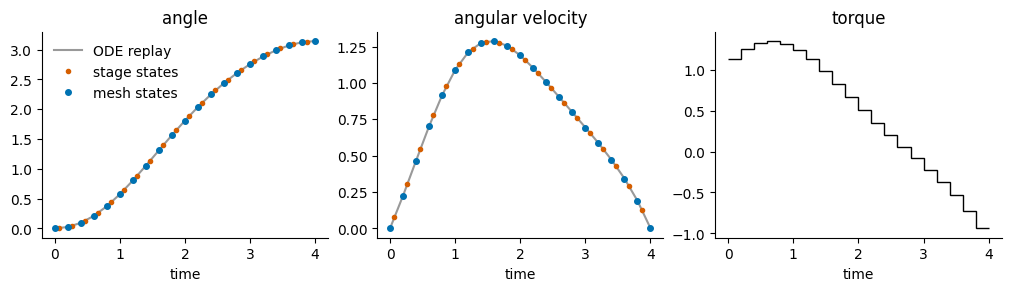

In [6]:
def replay(u):
    # Integrate the ODE accurately under the piecewise-constant torques.
    states = [x_start]
    for k in range(N):
        step = solve_ivp(lambda _, x: f(x, u[k]), [0, h], states[-1], rtol=1e-10, atol=1e-10)
        states.append(step.y[:, -1])
    return np.array(states)


x_replay = replay(u)
print(f"largest difference from the replay = {abs(x_mesh - x_replay).max():.1e}")

fig, axes = plt.subplots(1, 3, figsize=(10, 2.8), constrained_layout=True)
for i, name in enumerate(["angle", "angular velocity"]):
    axes[i].plot(t, x_replay[:, i], color="0.6", label="ODE replay")
    axes[i].plot(t_stage.ravel(), x_stage[:, :, i].ravel(), ".", color="#D55E00",
                 label="stage states")
    axes[i].plot(t, x_mesh[:, i], "o", color="#0072B2", markersize=4, label="mesh states")
    axes[i].set(xlabel="time", title=name)
axes[0].legend(frameon=False)
axes[2].stairs(u, t, baseline=None, color="black")
axes[2].set(xlabel="time", title="torque")
plt.show()

The replayed pendulum passes through the stored states and arrives upright
and at rest. The torque pushes during the first part of the motion and brakes
as the pendulum approaches the top.

## The same construction with derivatives

The integration form interpolates slopes and integrates them. The
differentiation form interpolates state values and differentiates them. On
each interval, the state polynomial has degree $s=2$, so three values
determine it. Store its values at $\tau=0$ and at the two collocation nodes.
These are $\mathbf x_k$, $\mathbf x_{k,1}$, and $\mathbf x_{k,2}$: the same
unknowns as before.

Let $\ell_0,\ell_1,\ell_2$ be the Lagrange basis for the three nodes
$(0,\tfrac{1}{3},1)$. The slope of the state polynomial at the collocation node
$\tau_i$ is a fixed combination of the stored values, with weights
$D_{ir}=\ell_r'(\tau_i)$. This slope is measured in local time, and one unit
of local time lasts $h$ units of physical time. The chapter's slope equations
therefore equate it to $h$ times the ODE slope:

$$
D_{i0}\mathbf x_k+\sum_{r=1}^{s}D_{ir}\mathbf x_{k,r}=h\mathbf f_{k,i}.
$$

By hand, the basis functions are

$$
\ell_0(\tau)=3\tau^2-4\tau+1,\qquad
\ell_1(\tau)=-\tfrac{9}{2}\tau^2+\tfrac{9}{2}\tau,\qquad
\ell_2(\tau)=\tfrac{3}{2}\tau^2-\tfrac{1}{2}\tau,
$$

with derivatives $6\tau-4$, $-9\tau+\tfrac{9}{2}$, and $3\tau-\tfrac{1}{2}$.
Evaluating these derivatives at $\tfrac{1}{3}$ and at $1$ gives one row of $D$
per collocation node:

$$
D=\begin{bmatrix}
-2&\tfrac{3}{2}&\tfrac{1}{2}\cr
2&-\tfrac{9}{2}&\tfrac{5}{2}
\end{bmatrix},
\qquad
\begin{aligned}
-2\mathbf x_k+\tfrac{3}{2}\mathbf x_{k,1}+\tfrac{1}{2}\mathbf x_{k,2}
&=h\mathbf f_{k,1},\cr
2\mathbf x_k-\tfrac{9}{2}\mathbf x_{k,1}+\tfrac{5}{2}\mathbf x_{k,2}
&=h\mathbf f_{k,2}.
\end{aligned}
$$

The endpoint equation evaluates the polynomial at $\tau=1$, using the weights
$e_r=\ell_r(1)$. Here $e=(0,0,1)$, so it reduces to
$\mathbf x_{k+1}=\mathbf x_{k,2}$. Compared with the integration form, the
rule and two lines of the constraint function change.

In [7]:
assert tau.min() > 0, "this section needs collocation nodes other than 0"

# D[i, r] is the slope of ell_r at tau_i, and e[r] is the value of ell_r at 1.
state_basis = lagrange_basis(np.append(0.0, tau))    # basis for the nodes 0, tau_1, ..., tau_s
D = np.array([[ell.deriv()(tau_i) for ell in state_basis] for tau_i in tau])
e = np.array([ell(1.0) for ell in state_basis])
show("D", D)
show("e", e)


def equalities_from_derivatives(z):                                     # H(z) = 0
    x_mesh, x_stage, u = unpack(z)
    residuals = [x_mesh[0] - x_start, x_mesh[N] - x_goal]               # boundary conditions
    for k in range(N):
        slopes = np.array([f(x_stage[k, j], u[k]) for j in range(s)])   # f at every stage
        values = np.vstack([x_mesh[k], x_stage[k]])                     # state at 0 and the nodes
        residuals.append(D @ values - h * slopes)                       # slope equations
        residuals.append(x_mesh[k + 1] - e @ values)                    # endpoint equation
    return np.concatenate([r.ravel() for r in residuals])


other = minimize(objective, z0, method="SLSQP", bounds=bounds,
                 constraints={"type": "eq", "fun": equalities_from_derivatives})
print(f"cost = {other.fun:.4f}")
print(f"largest difference between the two solutions = {abs(other.x - solution.x).max():.1e}")

D = [[-2, 3/2, 1/2], [2, -9/2, 5/2]]
e = [0, 0, 1]


cost = 3.0753
largest difference between the two solutions = 1.6e-07


Both programs have the same variables and the same objective, and their
constraints vanish at the same points. The solver therefore returns the same
trajectory, up to its tolerance.

## Experiments

Each experiment changes a few lines. Run all cells again after a change.

The first experiment replaces the nodes in Step 1. The same code then
produces the other schemes of the chapter, because only the numbers in $A$
and $b$ change. The table lists the largest difference from the replay
obtained with $N=20$.

| `tau` | Scheme | Difference from the replay |
|:--|:--|:--|
| `np.array([0.0])` | explicit Euler | $7\times10^{-1}$ |
| `np.array([1.0])` | implicit Euler | $8\times10^{-1}$ |
| `np.array([0.5])` | implicit midpoint | $4\times10^{-2}$ |
| `np.array([0.0, 1.0])` | trapezoidal | $9\times10^{-3}$ |
| `np.array([1/3, 1.0])` | Radau, two stages | $1\times10^{-3}$ |
| `0.5 + np.array([-1, 1]) * np.sqrt(3) / 6` | Gauss, two stages | $3\times10^{-5}$ |
| `np.array([0.0, 0.5, 1.0])` | Hermite-Simpson | $6\times10^{-6}$ |

Every row satisfies its own collocation equations to the solver's tolerance.
The rows differ in how well those equations represent the differential
equation. A node at $0$ runs through Step 5 and stops at the first line of
the last section, which stores the state at $0$ and at the collocation nodes
and needs these to be distinct. For the Gauss nodes, `show` prints rounded
fractions because the exact entries are irrational.

The second experiment refines the mesh. With the Radau nodes, set `N` to 5,
10, 20, and 40. The difference from the replay falls by a factor of about
eight each time `N` doubles.

The third experiment bounds the torque. Set `T = 8.0` and `N = 40`, and
replace `bounds = None` in Step 5 by bounds on the last `N` entries of
$\mathbf z$:

```python
bounds = [(None, None)] * (len(z0) - N) + [(-0.5, 0.5)] * N
```

The pendulum's energy changes at the rate $u\omega$, so one forward swing
through the angle $\pi$ adds at most $0.5\pi\approx1.57$, less than the $2$
needed to reach the top. The solver returns a trajectory that first swings
backward.